In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import os

/Users/ets/miniconda3/envs/torchmetal/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
import plotly.express as px
import pandas as pd
### plot point cloud on cylindrical coordinates using plotly
def plot_point_cloud(results, xy_range):
    df = pd.DataFrame(results)
    fig = px.scatter_3d(df, x='x', y='y', z='z', color='E', size='size', size_max=5)
    fig.update_traces(marker=dict(line=dict(width=0)))
    fig.update_layout(
        width=1000,
        height=800,
        scene=dict(
            xaxis=dict(range=[-xy_range, xy_range]),
            yaxis=dict(range=[-xy_range, xy_range]),
        )
    )
    fig.show()

## Dataset

In [4]:
from dataset import SimplePflowDataset

config = os.path.join(os.getcwd(), '../config/calo_flash_dataset.yaml')
dataset = SimplePflowDataset(config, batch_size=10)

In [5]:
for batch in dataset:
    print(batch['input_feats'].keys())
    print(batch['target_feats'].keys())
    print(batch['incidence_matrix'].shape)
    break

dict_keys(['hit_x', 'hit_y', 'hit_z', 'hit_e'])
dict_keys(['part_e', 'part_x', 'part_y'])
torch.Size([10, 32, 776])


In [6]:
print(batch['input_feats']['hit_x'].shape)

torch.Size([10, 775])


In [7]:
from utils import transform

ev = 0
X = batch['input_feats']
is_nan = torch.isnan(X['hit_x'][ev])
plot_dict = {k: transform(v[ev][~is_nan], k, dataset.xform_cfg, inverse=True) for k, v in X.items()}
plot_dict['x'] = plot_dict.pop('hit_x')
plot_dict['y'] = plot_dict.pop('hit_y')
plot_dict['z'] = plot_dict.pop('hit_z')
plot_dict['E'] = plot_dict.pop('hit_e')
plot_dict['size'] = (plot_dict['E'] + 1).log()

plot_point_cloud(plot_dict, xy_range=dataset.calo_cfg['width'])

/Users/ets/miniconda3/envs/torchmetal/lib/python3.12/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




## Feature distributions

In [8]:
import tqdm.notebook as tqdm

inputs  = {'hit_e': [], 'hit_x': [], 'hit_y': [], 'hit_z': []}
targets = {'part_e': [], 'part_x': [], 'part_y': []}
incidence_matrices = []

dataset = SimplePflowDataset(config, batch_size=1)

num_batches = 10000
for i, batch in tqdm.tqdm(enumerate(dataset), total=num_batches):
    if i >= num_batches:
        break
    for k in inputs.keys():
        x = batch['input_feats'][k]
        x = x[~torch.isnan(x)]
        inputs[k].append(x)
    for k in targets.keys():
        x = batch['target_feats'][k]
        x = x[~torch.isnan(x)]
        targets[k].append(x)
    
    incidence_matrices.append(batch['incidence_matrix'].flatten())

inputs = {k: torch.cat(v) for k, v in inputs.items()}
targets = {k: torch.cat(v) for k, v in targets.items()}
incidence_matrix = torch.cat(incidence_matrices)

targets['incidence_matrix'] = incidence_matrix

  0%|          | 0/10000 [00:00<?, ?it/s]

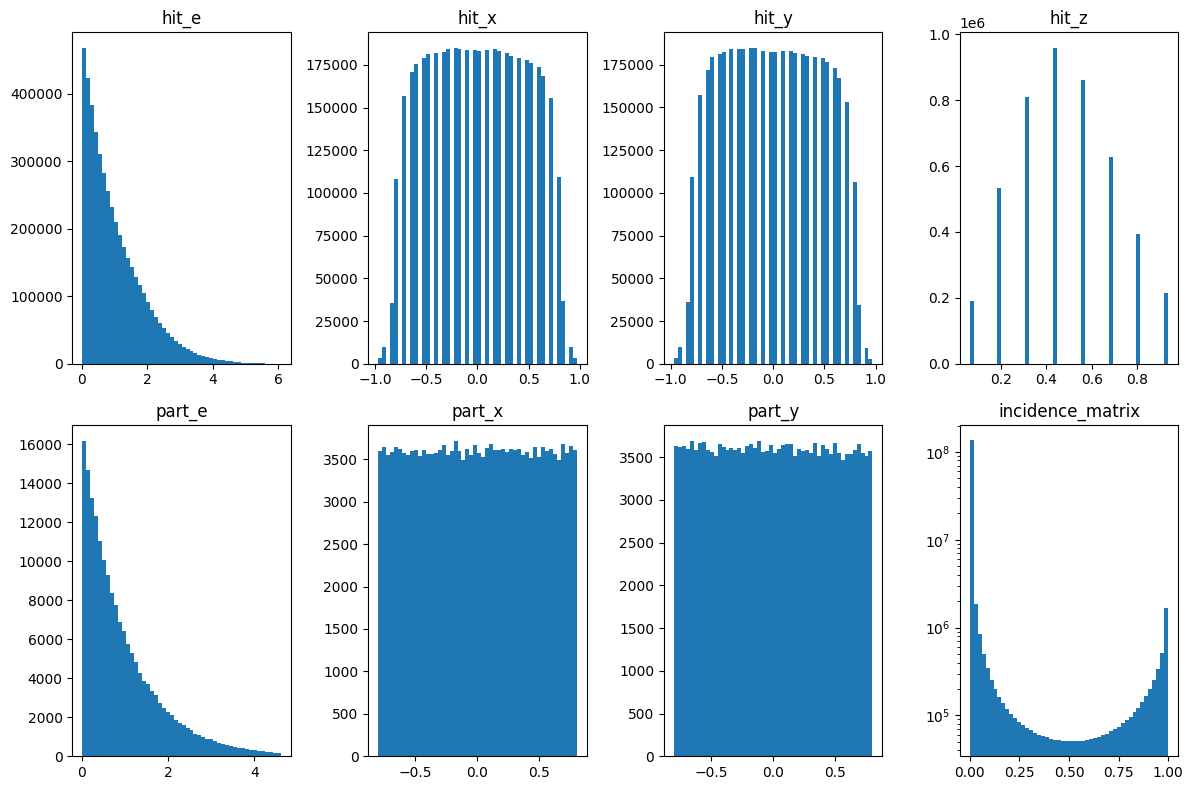

In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 4)
for i, feat in enumerate(inputs):
    ax = fig.add_subplot(gs[0, i])
    x = inputs[feat]
    ax.hist(x, bins=50)
    ax.set_title(feat)
for i, feat in enumerate(targets):
    ax = fig.add_subplot(gs[1, i])
    x = targets[feat]
    ax.hist(x, bins=50)
    ax.set_title(feat)
    if feat == 'incidence_matrix':
        ax.set_yscale('log')
plt.tight_layout()
plt.show()

